# Helmet Detection - Object Detection with YOLO

The classifier we built in `helmet_detection.ipynb` answers "is this photo helmet or no-helmet" for a single, pre-cropped rider. That's not useful on real traffic footage, where a frame can contain several riders at once and we need to know *where* each one is, not just *whether* a helmet exists somewhere in the frame.

This notebook builds an actual object detector using **YOLO** (via the `ultralytics` library), trained on a dataset that has real bounding-box annotations: [andrewmvd/helmet-detection](https://www.kaggle.com/datasets/andrewmvd/helmet-detection) (764 images, Pascal VOC XML annotations, classes `With helmet` / `Without helmet`).

Plan:
1. **Download & explore** the annotated dataset (this notebook, right now).
2. Convert Pascal VOC XML annotations to the format YOLO expects.
3. Split into train/val/test and write the YOLO dataset config file.
4. Fine-tune a pretrained YOLO model on our data.
5. Evaluate with detection-specific metrics (mAP, IoU) instead of accuracy.
6. Run inference on a new image and draw the predicted boxes.

Run this in **Google Colab** with a GPU runtime: `Runtime > Change runtime type > GPU`.

## Step 1: Download the dataset

In [3]:
!pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download("andrewmvd/helmet-detection")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'helmet-detection' dataset.
Path to dataset files: /kaggle/input/helmet-detection


## Step 2: Explore the folder structure and one annotation file

Unlike the classification dataset, this one should have two parallel folders: images and their matching XML annotation files (one XML per image, same base filename). Let's confirm that structure and look at what's actually inside one annotation file, since that tells us exactly what fields we need to parse (image size, object class names, box coordinates).

In [4]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")
    for f in files[:3]:
        print(f"{indent}  - {f}")
    if len(files) > 3:
        print(f"{indent}  ... and {len(files) - 3} more")

helmet-detection/  (0 files)
  annotations/  (764 files)
    - BikesHelmets338.xml
    - BikesHelmets680.xml
    - BikesHelmets62.xml
    ... and 761 more
  images/  (764 files)
    - BikesHelmets719.png
    - BikesHelmets219.png
    - BikesHelmets18.png
    ... and 761 more


In [5]:
# TODO: update these two paths once Step 2's output shows the real subfolder names
images_dir = os.path.join(path, "images")
annotations_dir = os.path.join(path, "annotations")

import glob

sample_xml = sorted(glob.glob(os.path.join(annotations_dir, "*.xml")))[0]
with open(sample_xml) as f:
    print(f.read())


<annotation>
    <folder>images</folder>
    <filename>BikesHelmets0.png</filename>
    <size>
        <width>400</width>
        <height>267</height>
        <depth>3</depth>
    </size>
    <segmented>0</segmented>
    <object>
        <name>With Helmet</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>29</xmin>
            <ymin>105</ymin>
            <xmax>82</xmax>
            <ymax>160</ymax>
        </bndbox>
    </object>
    <object>
        <name>With Helmet</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>122</xmin>
            <ymin>66</ymin>
            <xmax>193</xmax>
            <ymax>154</ymax>
        </bndbox>
    </object>
    <object>
        <name>With Helmet</name>
        <pose>Unspecified</pose>
        <truncated>0</tr

## Step 3: Check every class name and count objects

Before hardcoding a class mapping, let's scan all 764 XML files and collect every distinct `<name>` value that actually appears, plus how many boxes exist per class. We saw `"With Helmet"` in one file — we need to confirm the exact spelling of the other class (and check there isn't a third, unexpected one) across the whole dataset, and see how balanced it is.

In [6]:
import xml.etree.ElementTree as ET
from collections import Counter

class_counts = Counter()
images_with_no_objects = 0

for xml_path in sorted(glob.glob(os.path.join(annotations_dir, "*.xml"))):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    objects = root.findall("object")
    if not objects:
        images_with_no_objects += 1
    for obj in objects:
        class_counts[obj.find("name").text] += 1

print("Class counts (total boxes across all 764 images):")
for name, count in class_counts.most_common():
    print(f"  {name!r}: {count}")
print(f"\nImages with zero annotated objects: {images_with_no_objects}")

Class counts (total boxes across all 764 images):
  'With Helmet': 962
  'Without Helmet': 489

Images with zero annotated objects: 3


## Step 4: Convert Pascal VOC boxes to YOLO format

Pascal VOC stores a box as two corners in raw pixels: `(xmin, ymin)` top-left, `(xmax, ymax)` bottom-right. YOLO wants a different representation: `(x_center, y_center, width, height)`, each **normalized to a 0-1 fraction of the image size** (not pixels). Normalizing matters because it makes the label independent of the image's actual resolution — a box centered at the middle of the image is `x_center=0.5` whether the image is 400px or 4000px wide.

The conversion:
```
x_center = (xmin + xmax) / 2 / image_width
y_center = (ymin + ymax) / 2 / image_height
width    = (xmax - xmin) / image_width
height   = (ymax - ymin) / image_height
```

We also need to physically reorganize the files into the layout `ultralytics` expects:
```
yolo_dataset/
  images/train/*.png   labels/train/*.txt
  images/val/*.png     labels/val/*.txt
  images/test/*.png    labels/test/*.txt
```
Each label `.txt` has one line per object: `class_id x_center y_center width height`. We split at the **image** level (not per-box), and stratify by whether an image contains at least one `Without Helmet` box, so that minority-class images aren't accidentally clustered into just one split.

In [7]:
import shutil
from sklearn.model_selection import train_test_split
from PIL import Image

CLASS_NAMES = ["With Helmet", "Without Helmet"]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}

YOLO_ROOT = "/content/yolo_dataset"

def parse_annotation(xml_path, image_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Trust the actual image file's pixel size, not the XML's <size> tag:
    # a couple of files in this dataset have XML dimensions that don't match
    # the real image, which produces out-of-range normalized coordinates.
    with Image.open(image_path) as img:
        img_w, img_h = img.size

    boxes = []
    skipped = 0
    for obj in root.findall("object"):
        class_id = CLASS_TO_ID[obj.find("name").text]
        bnd = obj.find("bndbox")
        xmin, ymin = int(bnd.find("xmin").text), int(bnd.find("ymin").text)
        xmax, ymax = int(bnd.find("xmax").text), int(bnd.find("ymax").text)

        # clip to valid image bounds instead of trusting the annotation blindly
        xmin, xmax = max(0, xmin), min(img_w, xmax)
        ymin, ymax = max(0, ymin), min(img_h, ymax)

        if xmax <= xmin or ymax <= ymin:
            skipped += 1
            continue

        boxes.append((class_id, xmin, ymin, xmax, ymax))
    return img_w, img_h, boxes, skipped

def voc_to_yolo_line(class_id, xmin, ymin, xmax, ymax, img_w, img_h):
    x_center = (xmin + xmax) / 2 / img_w
    y_center = (ymin + ymax) / 2 / img_h
    width = (xmax - xmin) / img_w
    height = (ymax - ymin) / img_h
    return f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"

# gather every image's base name + whether it contains a "Without Helmet" box (for stratified split)
xml_paths = sorted(glob.glob(os.path.join(annotations_dir, "*.xml")))
base_names = []
stratify_labels = []
parsed = {}  # base_name -> (img_w, img_h, boxes)

for xml_path in xml_paths:
    base_name = os.path.splitext(os.path.basename(xml_path))[0]
    image_path = os.path.join(images_dir, base_name + ".png")
    img_w, img_h, boxes, skipped = parse_annotation(xml_path, image_path)
    if skipped:
        print(f"  {base_name}: skipped {skipped} degenerate box(es) after clipping to real image bounds")
    parsed[base_name] = (img_w, img_h, boxes)
    base_names.append(base_name)
    has_without_helmet = any(c == CLASS_TO_ID["Without Helmet"] for c, *_ in boxes)
    stratify_labels.append(int(has_without_helmet))

train_names, temp_names, train_strat, temp_strat = train_test_split(
    base_names, stratify_labels, test_size=0.3, stratify=stratify_labels, random_state=42
)
val_names, test_names = train_test_split(
    temp_names, test_size=0.5, stratify=temp_strat, random_state=42
)

splits = {"train": train_names, "val": val_names, "test": test_names}
print({k: len(v) for k, v in splits.items()})

for split, names in splits.items():
    os.makedirs(os.path.join(YOLO_ROOT, "images", split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_ROOT, "labels", split), exist_ok=True)
    for base_name in names:
        img_w, img_h, boxes = parsed[base_name]
        src_image = os.path.join(images_dir, base_name + ".png")
        shutil.copy2(src_image, os.path.join(YOLO_ROOT, "images", split, base_name + ".png"))

        label_lines = [voc_to_yolo_line(*box, img_w, img_h) for box in boxes]
        with open(os.path.join(YOLO_ROOT, "labels", split, base_name + ".txt"), "w") as f:
            f.write("\n".join(label_lines))

print("Done. Example label file:")
with open(os.path.join(YOLO_ROOT, "labels", "train", train_names[0] + ".txt")) as f:
    print(f.read())

  BikesHelmets103: skipped 1 degenerate box(es) after clipping to real image bounds
  BikesHelmets140: skipped 1 degenerate box(es) after clipping to real image bounds
  BikesHelmets205: skipped 1 degenerate box(es) after clipping to real image bounds
  BikesHelmets279: skipped 1 degenerate box(es) after clipping to real image bounds
  BikesHelmets326: skipped 1 degenerate box(es) after clipping to real image bounds
  BikesHelmets343: skipped 1 degenerate box(es) after clipping to real image bounds
  BikesHelmets441: skipped 1 degenerate box(es) after clipping to real image bounds
  BikesHelmets444: skipped 1 degenerate box(es) after clipping to real image bounds
  BikesHelmets530: skipped 1 degenerate box(es) after clipping to real image bounds
  BikesHelmets616: skipped 1 degenerate box(es) after clipping to real image bounds
  BikesHelmets671: skipped 1 degenerate box(es) after clipping to real image bounds
  BikesHelmets706: skipped 1 degenerate box(es) after clipping to real image

## Step 5: Write the YOLO dataset config file

`ultralytics` needs a small YAML file telling it where the images live and what the classes are — this is the detection equivalent of the `class_dirs` dict we used for the classifier.

In [8]:
data_yaml = f"""
path: {YOLO_ROOT}
train: images/train
val: images/val
test: images/test

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""

data_yaml_path = os.path.join(YOLO_ROOT, "data.yaml")
with open(data_yaml_path, "w") as f:
    f.write(data_yaml)

print(data_yaml)


path: /content/yolo_dataset
train: images/train
val: images/val
test: images/test

nc: 2
names: ['With Helmet', 'Without Helmet']



## Step 6: Fine-tune a pretrained YOLO model

Same transfer-learning principle as MobileNetV2, applied to detection: we start from a pretrained YOLOv8 checkpoint (already trained on COCO), and fine-tune it on our 2 classes.

**Third attempt.** The v2 run (`yolov8s` + `copy_paste`/`mixup`) showed those augmentations didn't actually help `Without Helmet` (likely because `copy_paste` needs segmentation masks, which this bbox-only dataset doesn't have) — so we're dropping them and instead spending compute more directly:
- **`yolov8m.pt`** instead of `yolov8s.pt` — roughly 2.3x more parameters, the highest ceiling of the practical options.
- **`imgsz=960`** instead of `640` — more spatial detail per image, which should help most with smaller/farther-away objects and tighter box placement (the `mAP50-95` score, which penalizes loose boxes).
- **`batch=-1`** — lets `ultralytics` auto-pick the largest batch size that fits in GPU memory, since a bigger model at higher resolution uses meaningfully more memory than our last run.
- Output goes to `helmet_yolo_v3` so we can keep comparing against both earlier runs.

This will be the slowest run yet — bigger model, higher resolution, same epoch budget (100, patience 20). Expect it to take a while.

In [9]:
!pip install -q ultralytics

from ultralytics import YOLO

yolo_model = YOLO("yolov8m.pt")  # pretrained on COCO, "medium" variant

train_results = yolo_model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=960,
    batch=-1,
    patience=20,
    project=YOLO_ROOT,
    name="helmet_yolo_v3",
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=helmet_yolo_v3, nbs=64, nms=None, opset=None

## Step 7: Evaluate on the untouched test set

The metrics table printed during training was computed on the **validation** split (used to monitor training, same as our `val_ds` before). Now let's run one honest evaluation pass on the **test** split — the 115 images this model has never influenced any decision from.

In [10]:
test_metrics = yolo_model.val(data=data_yaml_path, split="test")

print(f"\nmAP50 (all classes):    {test_metrics.box.map50:.3f}")
print(f"mAP50-95 (all classes): {test_metrics.box.map:.3f}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: mAP50={test_metrics.box.ap50[i]:.3f}  mAP50-95={test_metrics.box.ap[i]:.3f}")

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 92 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 77.7±24.0 MB/s, size: 557.4 KB)
val: Scanning /content/yolo_dataset/labels/test.cache... 115 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 28.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.0it/s 8.0s0.9ss
                   all        115        196      0.721      0.753       0.77      0.473
           With Helmet         88        128      0.765      0.844       0.88       0.57
        Without Helmet         39         68      0.676      0.662      0.661      0.376
Speed: 12.5ms preprocess, 32.6ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to /content/runs/detect/val-3

mAP50 (all classes):    0.770
mAP50-95 (all classes): 0.473
  With Helmet: mAP50=0.880  mA

## Step 8: Visualize predicted boxes

This is the real difference from the classifier: instead of one label per image, we now get a variable number of boxes, each with its own class and confidence score, drawn directly on the photo.


0: 960x960 1 With Helmet, 51.6ms
1: 960x960 (no detections), 51.6ms
2: 960x960 1 With Helmet, 1 Without Helmet, 51.6ms
3: 960x960 2 With Helmets, 51.6ms
4: 960x960 1 With Helmet, 51.6ms
5: 960x960 1 With Helmet, 51.6ms
Speed: 3.1ms preprocess, 51.6ms inference, 0.9ms postprocess per image at shape (1, 3, 960, 960)


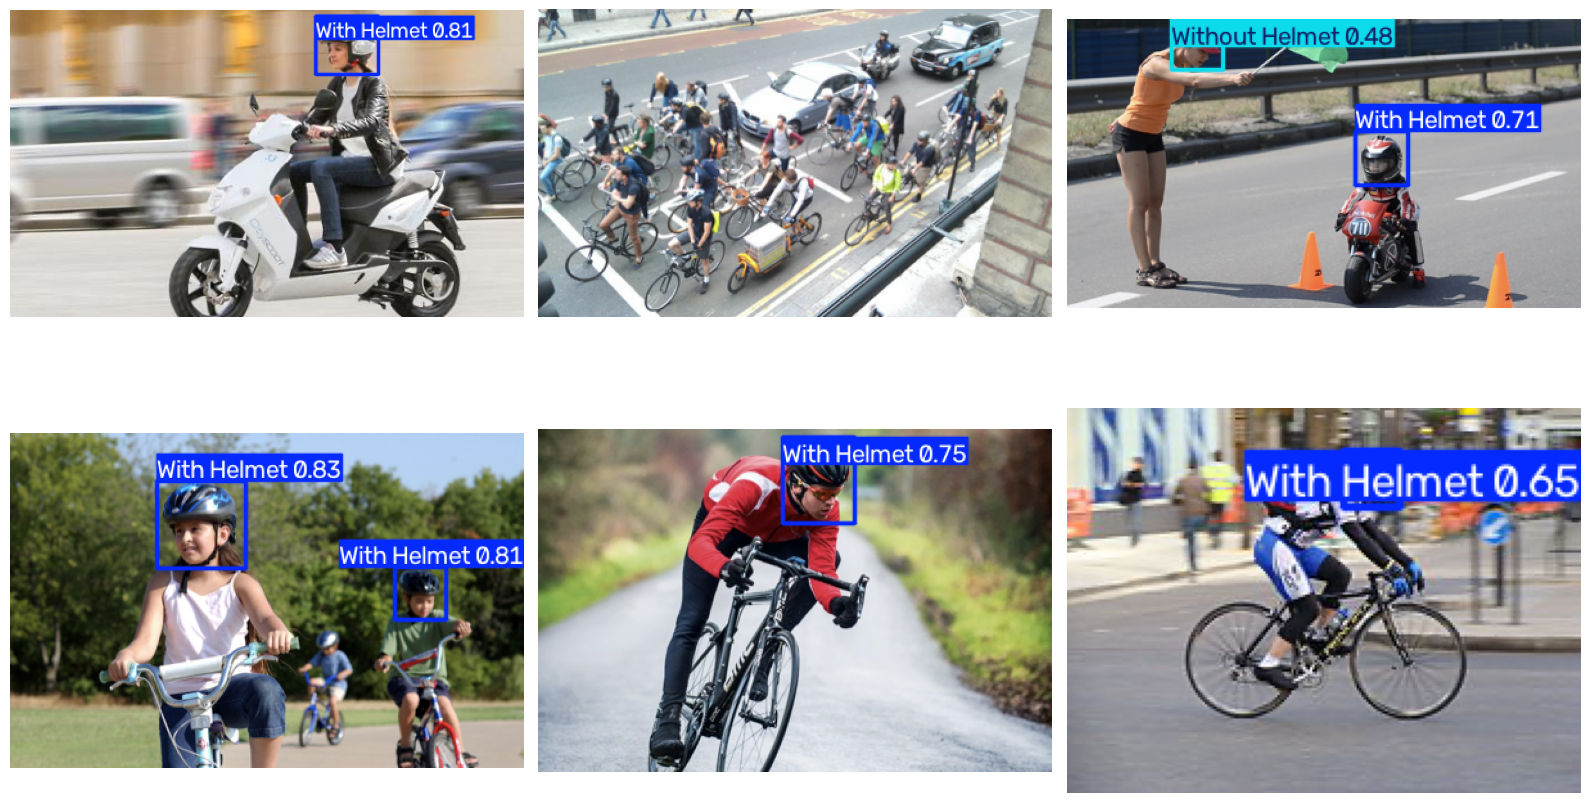

In [15]:
import random
import matplotlib.pyplot as plt

test_images = glob.glob(os.path.join(YOLO_ROOT, "images", "test", "*.png"))
sample_images = random.sample(test_images, 6)

results = yolo_model.predict(sample_images, conf=0.4)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, result in zip(axes.flat, results):
    annotated = result.plot()  # returns a BGR numpy array with boxes/labels drawn
    ax.imshow(annotated[:, :, ::-1])  # BGR -> RGB for matplotlib
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 9: Save the trained weights

`ultralytics` already saved checkpoints during training to `YOLO_ROOT/helmet_yolo/weights/best.pt` (best validation loss) and `last.pt`. Colab runtimes are temporary, so let's download `best.pt` before this session disappears.

In [16]:
from google.colab import files

best_weights_path = os.path.join(YOLO_ROOT, "helmet_yolo_v3", "weights", "best.pt")
files.download(best_weights_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 10: Run inference on a brand-new photo

Find a photo online with multiple motorcycle riders in it (right-click → "Copy image address"), paste the URL below, and run this cell. This is the scenario our classifier fundamentally couldn't handle — a scene with several people, each needing their own detection.


image 1/1 /content/new_photo.jpg: 896x960 1 With Helmet, 72.3ms
Speed: 4.0ms preprocess, 72.3ms inference, 1.6ms postprocess per image at shape (1, 3, 896, 960)


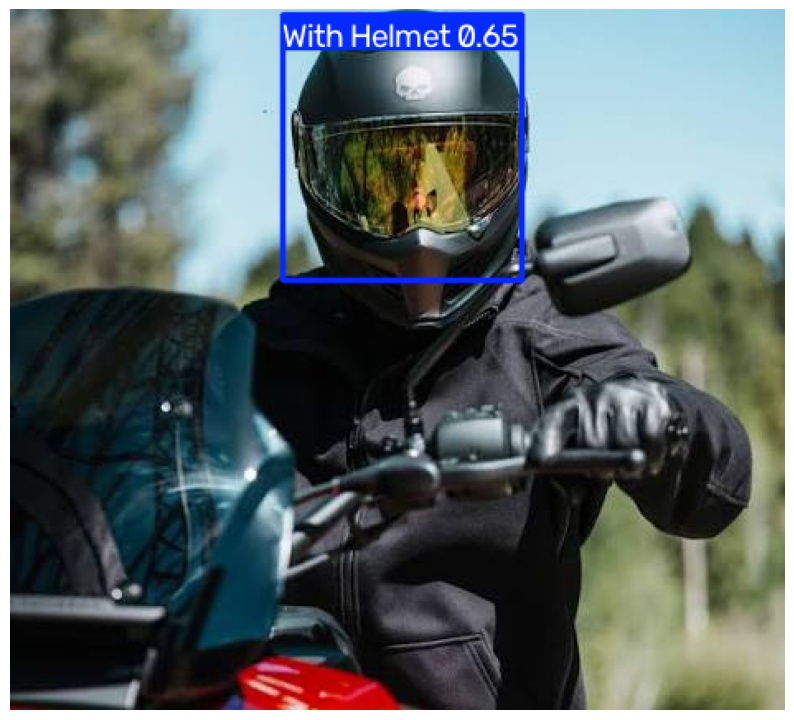

Detected 1 object(s):
  With Helmet: 0.65 confidence


In [19]:
import urllib.request

IMAGE_URL = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRsHYyNr0x2kwyCw9RBaWRSj3IVy1d_FhtHiveD2OkNE8tJVYhSiKrVeXw&s=10"
new_image_path = "new_photo.jpg"
urllib.request.urlretrieve(IMAGE_URL, new_image_path)

result = yolo_model.predict(new_image_path, conf=0.4)[0]
annotated = result.plot()

plt.figure(figsize=(10, 10))
plt.imshow(annotated[:, :, ::-1])
plt.axis("off")
plt.show()

print(f"Detected {len(result.boxes)} object(s):")
for box in result.boxes:
    class_name = CLASS_NAMES[int(box.cls)]
    confidence = float(box.conf)
    print(f"  {class_name}: {confidence:.2f} confidence")